<a href="https://colab.research.google.com/github/arxsyy/PCVK_Ganjil_2026/blob/main/Week5_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Marsyalia Fernanda'
NIM = '244107020133'

N = int(NIM[-3:])
PARAM = {
    'bins' : 2 ** ((N % 4) + 3),
    'clip' : round(1.0 + (N % 5) * 0.5, 1),
    'tile' : (N % 4) + 2,
    'L'    : 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)

print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Marsyalia Fernanda
NIM    : 244107020133 | N = 133
bins   : 16
clip   : 2.5
tile   : 3
L      : 4
WAKTU  : 2026-09-29 17:01:52 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : da00de117fb5b6d2


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

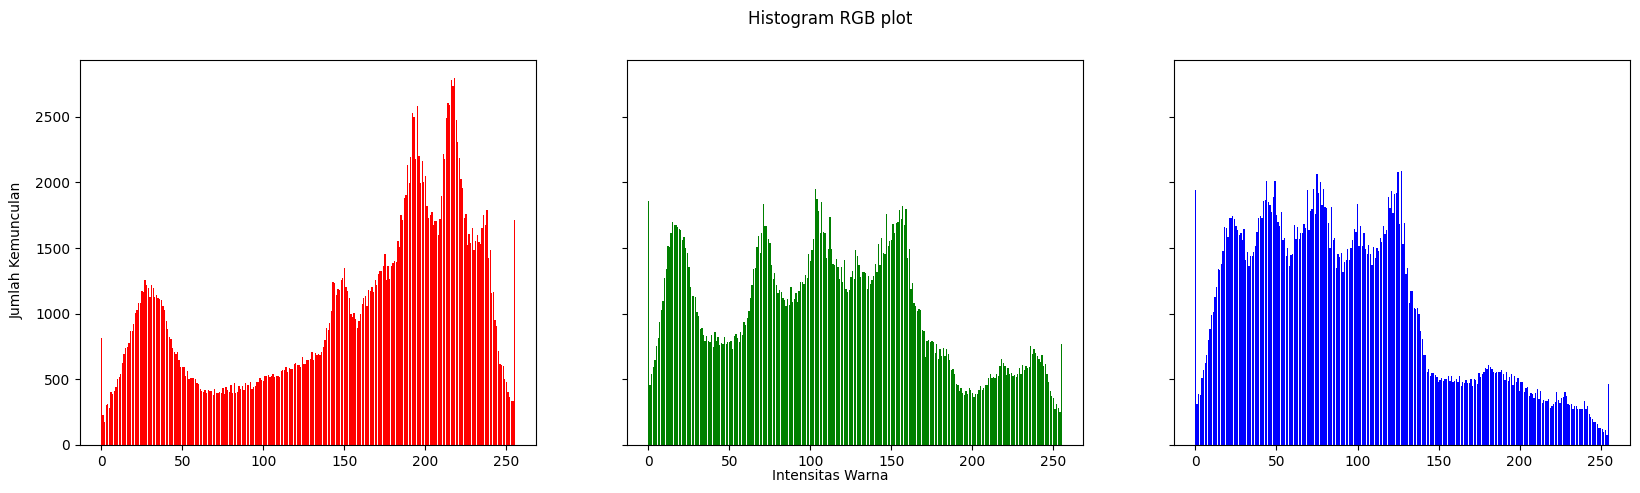

In [4]:
#membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/PCVK/Images/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height) :
  for x in range(0, width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1


names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()
#

In [5]:
def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [6]:
CONTOH = '/content/drive/MyDrive/PCVK/Images'
BASE = '/content/drive/MyDrive/PCVK/Images'

**1A. Verifikasi pada lena.jpg**

In [7]:
gray_lena = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)

# Histogram manual
hist_manual = histogram_manual(gray_lena)

# Histogram menggunakan NumPy
hist_numpy, _ = np.histogram(
    gray_lena,
    bins=256,
    range=(0, 256)
)

# Histogram menggunakan OpenCV
hist_cv = cv.calcHist(
    [gray_lena],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# Hitung selisih maksimum
selisih_manual_numpy = np.max(np.abs(hist_manual - hist_numpy))
selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
selisih_numpy_cv = np.max(np.abs(hist_numpy - hist_cv))

print('Selisih maksimum Manual vs NumPy :', selisih_manual_numpy)
print('Selisih maksimum Manual vs CV2   :', selisih_manual_cv)
print('Selisih maksimum NumPy vs CV2    :', selisih_numpy_cv)

Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs CV2   : 0.0
Selisih maksimum NumPy vs CV2    : 0.0


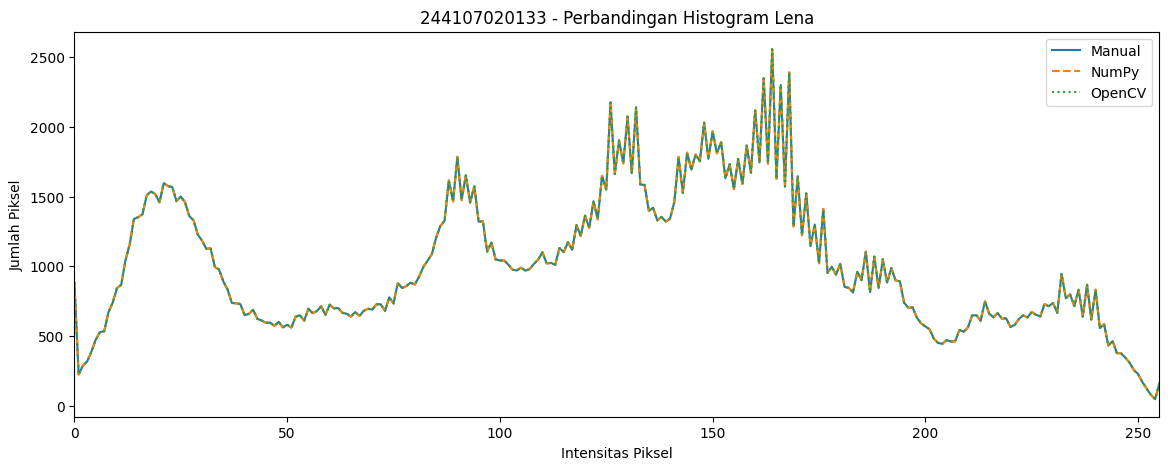

In [8]:
# Menampilkan ketiga histogram
plt.figure(figsize=(14, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_numpy, linestyle='--', label='NumPy')
plt.plot(hist_cv, linestyle=':', label='OpenCV')

plt.title(NIM + ' - Perbandingan Histogram Lena')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])
plt.legend()

plt.show()

**1B. Ulangi pada KTM1b.jpg**

In [10]:
gray_ktm1b = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)

# Histogram manual
hist_manual_ktm = histogram_manual(gray_ktm1b)

# Histogram NumPy
hist_numpy_ktm, _ = np.histogram(
    gray_ktm1b,
    bins=256,
    range=(0, 256)
)

# Histogram OpenCV
hist_cv_ktm = cv.calcHist(
    [gray_ktm1b],
    [0],
    None,
    [256],
    [0, 256]
).flatten()

# Selisih maksimum
selisih_manual_numpy = np.max(
    np.abs(hist_manual_ktm - hist_numpy_ktm)
)

selisih_manual_cv = np.max(
    np.abs(hist_manual_ktm - hist_cv_ktm)
)

selisih_numpy_cv = np.max(
    np.abs(hist_numpy_ktm - hist_cv_ktm)
)

print('Selisih maksimum Manual vs NumPy :', selisih_manual_numpy)
print('Selisih maksimum Manual vs CV2   :', selisih_manual_cv)
print('Selisih maksimum NumPy vs CV2    :', selisih_numpy_cv)

Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs CV2   : 0.0
Selisih maksimum NumPy vs CV2    : 0.0


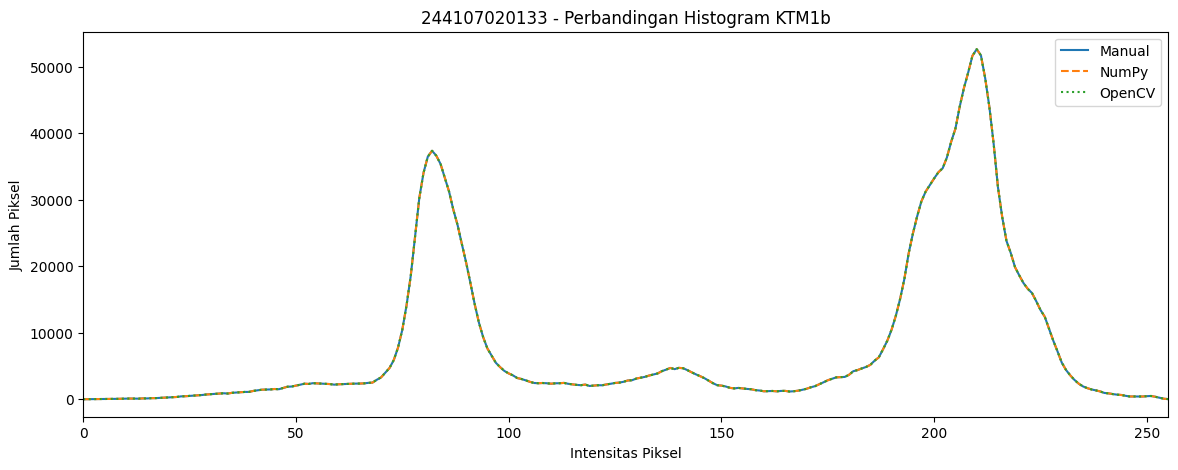

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(hist_manual_ktm, label='Manual')
plt.plot(hist_numpy_ktm, linestyle='--', label='NumPy')
plt.plot(hist_cv_ktm, linestyle=':', label='OpenCV')

plt.title(NIM + ' - Perbandingan Histogram KTM1b')
plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])
plt.legend()

plt.show()

**2. Histogram Ternormalisasi dan CDF KTM1a–KTM1d**

In [12]:
def histogram_dan_cdf(gray):
    hist = histogram_manual(gray)

    # Histogram ternormalisasi
    p = hist / gray.size

    # CDF
    cdf = np.cumsum(p)

    return p, cdf

In [13]:
nama_file = [
    'KTM1a.jpg',
    'KTM1b.jpg',
    'KTM1c.jpg',
    'KTM1d.jpg'
]

judul = [
    'KTM1a - Ruangan Gelap',
    'KTM1b - Lampu Ruangan',
    'KTM1c - Flash',
    'KTM1d - Cahaya Matahari'
]

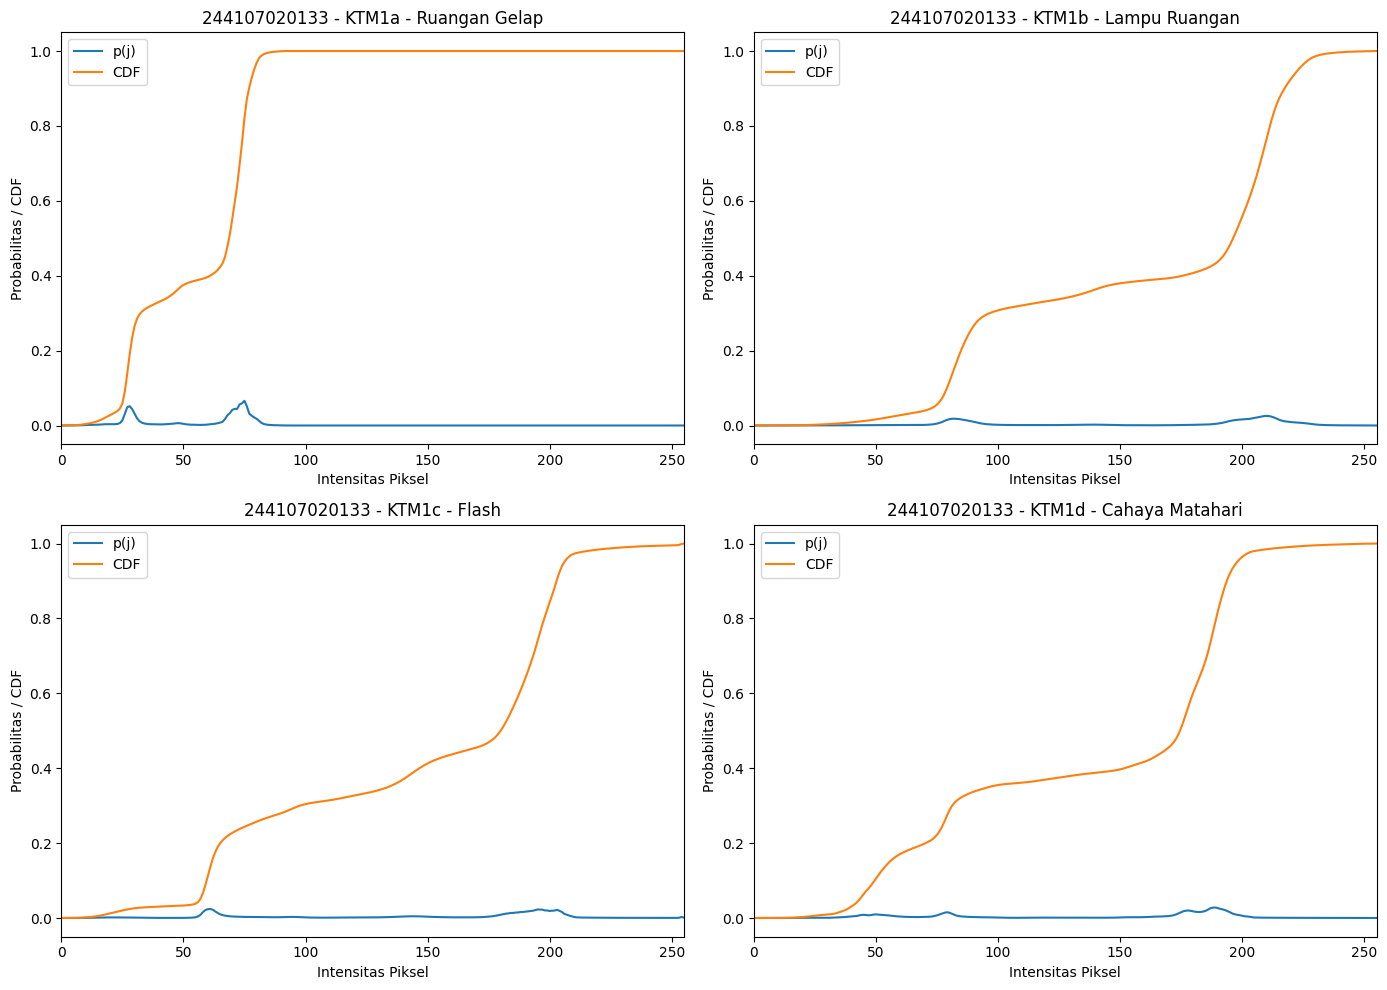

In [14]:
plt.figure(figsize=(14, 10))

for i, (file, nama) in enumerate(zip(nama_file, judul), 1):

    gray = cv.imread(
        BASE + '/' + file,
        cv.IMREAD_GRAYSCALE
    )

    p, cdf = histogram_dan_cdf(gray)

    plt.subplot(2, 2, i)

    plt.plot(p, label='p(j)')
    plt.plot(cdf, label='CDF')

    plt.title(NIM + ' - ' + nama)
    plt.xlabel('Intensitas Piksel')
    plt.ylabel('Probabilitas / CDF')
    plt.xlim([0, 255])
    plt.legend()

plt.tight_layout()
plt.show()

In [15]:
for file, nama in zip(nama_file, judul):

    gray = cv.imread(
        BASE + '/' + file,
        cv.IMREAD_GRAYSCALE
    )

    print(
        nama,
        '- Rata-rata intensitas:',
        round(gray.mean(), 2)
    )

KTM1a - Ruangan Gelap - Rata-rata intensitas: 56.64
KTM1b - Lampu Ruangan - Rata-rata intensitas: 161.66
KTM1c - Flash - Rata-rata intensitas: 146.81
KTM1d - Cahaya Matahari - Rata-rata intensitas: 139.42


**3. Perbandingan PARAM['bins'] dengan 256 Bin**

In [17]:
print("Jumlah bin berdasarkan NIM =", PARAM['bins'])

Jumlah bin berdasarkan NIM = 16


In [18]:
gray = cv.imread(
    BASE + '/KTM1b.jpg',
    cv.IMREAD_GRAYSCALE
)

In [19]:
hist_param, batas_param = np.histogram(
    gray,
    bins=PARAM['bins'],
    range=(0, 256)
)

hist_256, batas_256 = np.histogram(
    gray,
    bins=256,
    range=(0, 256)
)

In [20]:
pusat_param = (
    batas_param[:-1] + batas_param[1:]
) / 2

pusat_256 = (
    batas_256[:-1] + batas_256[1:]
) / 2

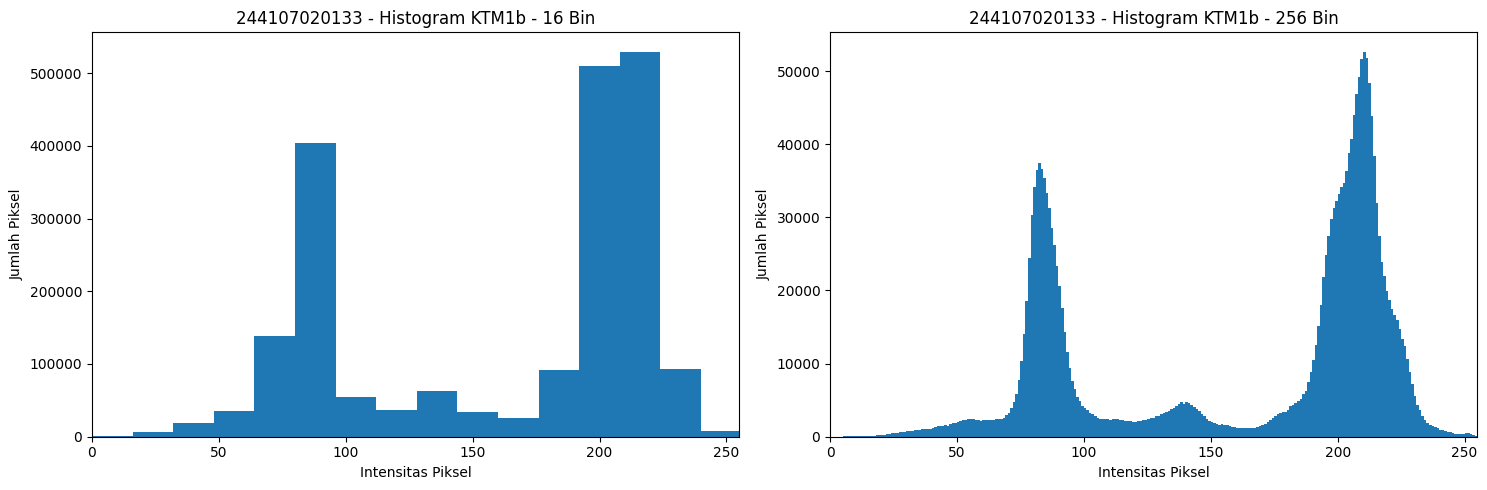

In [21]:
plt.figure(figsize=(15, 5))

# PARAM['bins']
plt.subplot(1, 2, 1)

plt.bar(
    pusat_param,
    hist_param,
    width=256 / PARAM['bins']
)

plt.title(
    NIM + ' - Histogram KTM1b - ' +
    str(PARAM['bins']) + ' Bin'
)

plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])


# 256 bin
plt.subplot(1, 2, 2)

plt.bar(
    pusat_256,
    hist_256,
    width=1
)

plt.title(
    NIM + ' - Histogram KTM1b - 256 Bin'
)

plt.xlabel('Intensitas Piksel')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 255])

plt.tight_layout()
plt.show()